In [1]:

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np


In [2]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:

zip_file_path = "/content/drive/MyDrive/AI/workshop5/FruitinAmazon.zip"
extract_path = "/content/"

# Unzip the file silently (-q) to the specified extraction path (-d)
!unzip -q "{zip_file_path}" -d "{extract_path}"

print(f"Successfully extracted '{zip_file_path}' to '{extract_path}'.")

Successfully extracted '/content/drive/MyDrive/AI/workshop5/FruitinAmazon.zip' to '/content/'.


['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


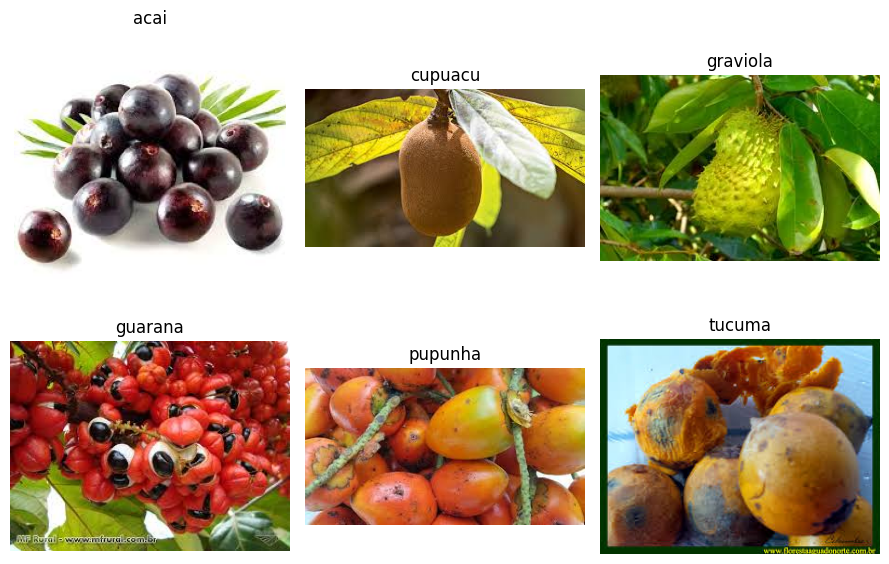

In [5]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

train_data_path = "/content/FruitinAmazon/train"
test_data_path = "/content/FruitinAmazon/test"

class_names = sorted([d for d in os.listdir(train_data_path) if os.path.isdir(os.path.join(train_data_path, d))])

print(class_names)

selected_images_paths = []
selected_class_names = []

for class_name in class_names:
    class_dir = "/content/FruitinAmazon/train/" + class_name

    image_files = [f for f in os.listdir(class_dir)]

    if image_files:
        random_image_name = random.choice(image_files)
        selected_images_paths.append(os.path.join(class_dir, random_image_name))
        selected_class_names.append(class_name)
    else:
        print(f"Warning: No image files found in class directory: {class_dir}")

num_images = len(selected_images_paths)
num_rows = 2
num_cols = (num_images + num_rows - 1) // num_rows
plt.figure(figsize=(num_cols * 3, num_rows * 3))

for i, img_path in enumerate(selected_images_paths):
    try:
        img = Image.open(img_path)
        plt.subplot(num_rows, num_cols, i + 1)
        plt.imshow(img)
        plt.title(selected_class_names[i])
        plt.axis("off")
    except Exception as e:
        print(f"Error loading or displaying image {img_path}: {e}")

plt.tight_layout()
plt.show()

In [6]:
corrupted_images = []

for class_name in os.listdir(train_data_path):
    class_dir = os.path.join(train_data_path, class_name)

    if os.path.isdir(class_dir):
        for image_name in os.listdir(class_dir):
            image_path = os.path.join(class_dir, image_name)

            if os.path.isfile(image_path):
                try:
                    img = Image.open(image_path)
                    img.verify()
                except (IOError, SyntaxError) as e:
                    print(f"Removed corrupted image: {image_path}")
                    corrupted_images.append(image_path)
                    os.remove(image_path)
                except Exception as e:
                    print(f"An unexpected error occurred with {image_path}: {e}")
                    corrupted_images.append(image_path)

if not corrupted_images:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


In [7]:
img_height = 128
img_width = 128
batch_size = 32

validation_split = 0.2

rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  train_data_path,
  labels="inferred",
  label_mode="int",
  image_size=(img_height, img_width),
  interpolation="nearest",
  batch_size=batch_size,
  shuffle=True,
  validation_split=validation_split,
  subset="training",
  seed=123
)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  train_data_path,
  labels="inferred",
  label_mode="int",
  image_size=(img_height, img_width),
  interpolation="nearest",
  batch_size=batch_size,
  shuffle=False,
  validation_split=validation_split,
  subset="validation",
  seed=123
)

val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [8]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
  test_data_path,
  labels = 'inferred',
  label_mode = 'int',
  image_size = (img_height, img_width),
  interpolation = 'nearest',
  batch_size = batch_size,
  shuffle = False,
  seed = 123
)
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

Found 30 files belonging to 6 classes.


In [9]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

num_classes = len(class_names)

model = keras.Sequential([
  layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(img_height, img_width, 3)),
  layers.MaxPooling2D((2, 2)),
  layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
  layers.MaxPooling2D((2, 2)),
  layers.Flatten(),
  layers.Dense(64, activation='relu'),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

checkpoint_filepath = 'best_model.weights.h5'
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True
)

early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(train_ds,validation_data=val_ds,epochs=250, batch_size=16, callbacks=[model_checkpoint_callback, early_stopping_callback])

loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

for images, labels in val_ds.take(1):
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)
    print("\nSample Predictions:")
    print("Predicted labels:", [class_names[p] for p in predicted_labels[:5]])
    print("Actual labels: ", [class_names[l] for l in labels.numpy()[:5]])

Epoch 1/250


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 588ms/step - accuracy: 0.1250 - loss: 2.0493 - val_accuracy: 0.2222 - val_loss: 1.5004
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 456ms/step - accuracy: 0.3333 - loss: 1.7536 - val_accuracy: 0.7222 - val_loss: 1.4377
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 407ms/step - accuracy: 0.4167 - loss: 1.5015 - val_accuracy: 0.4444 - val_loss: 1.6483
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 465ms/step - accuracy: 0.4722 - loss: 1.3151 - val_accuracy: 0.8333 - val_loss: 1.0720
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 681ms/step - accuracy: 0.7361 - loss: 1.0582 - val_accuracy: 0.4444 - val_loss: 1.2671
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 753ms/step - accuracy: 0.6389 - loss: 0.8878 - val_accuracy: 0.8333 - val_loss: 0.8384
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 483ms/step - accuracy: 0.8472 - loss: 0.5991 - val_accuracy: 0.7778 - val_loss: 0.8630
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 420ms/step - accuracy: 0.8750 - loss: 0.4941 - val_accuracy: 0.7778 - val_loss: 0.7

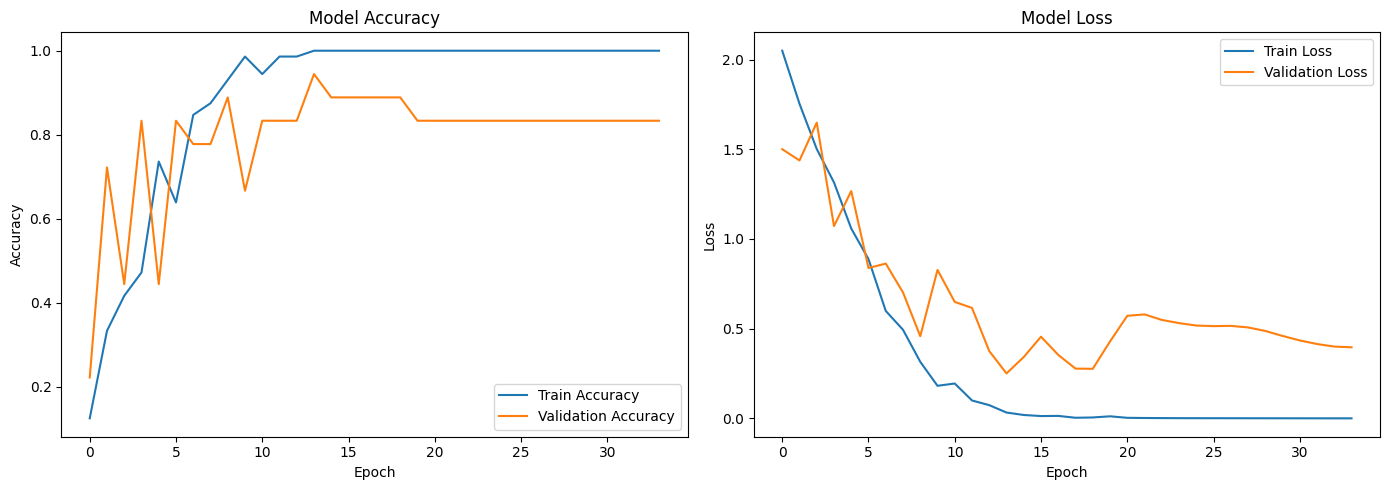

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
plt.tight_layout()
plt.show()

In [11]:
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.9444 - loss: 0.2506
Validation Loss: 0.2506
Validation Accuracy: 0.9444


In [12]:
model_save_path = 'fruit_classifier_model.h5'
model.save(model_save_path)
print(f"Model saved to {model_save_path}")

Model saved to fruit_classifier_model.h5


In [13]:
loaded_model = keras.models.load_model('fruit_classifier_model.h5')
print("Model loaded successfully!")

loaded_loss, loaded_accuracy = loaded_model.evaluate(val_ds)
print(f"\nLoaded Model Validation Loss: {loaded_loss:.4f}")
print(f"Loaded Model Validation Accuracy: {loaded_accuracy:.4f}")

Model loaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9444 - loss: 0.2506

Loaded Model Validation Loss: 0.2506
Loaded Model Validation Accuracy: 0.9444


In [14]:
from sklearn.metrics import classification_report

y_true = []
y_pred_probs = []

for images, labels in test_ds:
  preds = loaded_model.predict(images, verbose=0)
  y_pred_probs.extend(preds)
  y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.argmax(np.array(y_pred_probs), axis=1)
print('Predicted labels:', [class_names[i] for i in y_pred[:5]])
print('Actual labels :', [class_names[i] for i in y_true[:5]])

print(classification_report(y_true, y_pred, target_names=class_names))

Predicted labels: ['acai', 'cupuacu', 'acai', 'acai', 'acai']
Actual labels : ['acai', 'acai', 'acai', 'acai', 'acai']
              precision    recall  f1-score   support

        acai       0.67      0.80      0.73         5
     cupuacu       0.62      1.00      0.77         5
    graviola       1.00      1.00      1.00         5
     guarana       1.00      0.60      0.75         5
     pupunha       0.83      1.00      0.91         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.80        30
   macro avg       0.85      0.80      0.79        30
weighted avg       0.85      0.80      0.79        30



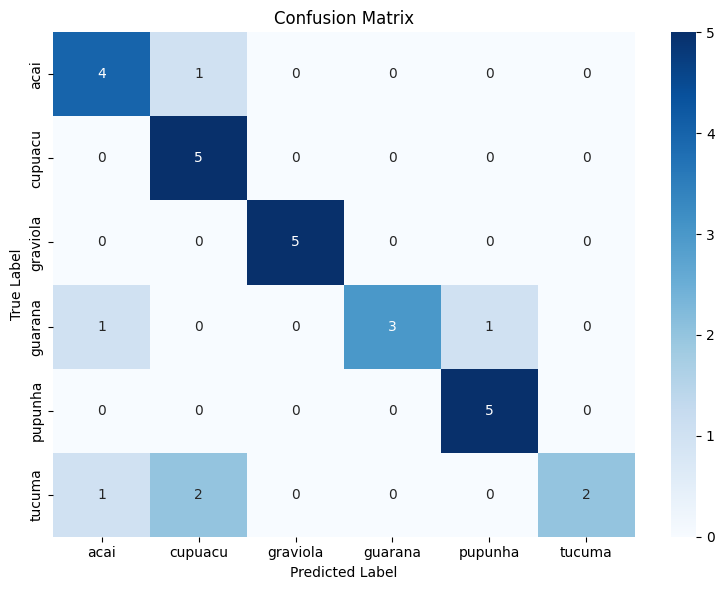

In [15]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()